# Welo absenteeism pipeline: end-to-end demo

A single-notebook walkthrough of the full pipeline:

1. Ingest pulls the canonical schema from one or more adapters (UCI today, Glencore tomorrow).
2. Validate profiles the schema, the missingness, and the plausibility of every field.
3. Features engineers clinically meaningful inputs alongside the risk-band target.
4. Train fits a regression model for predicted absent hours and a classification model for the risk band, both with cross-validation.
5. Score produces per-employee predictions.
6. Explain derives SHAP-based global feature importance and per-employee top reasons.
7. Export writes a `dashboard_feed.json` shaped exactly to the panels in `index.html`.

Read this first. The 200-row UCI sample is augmented with 800 rows of plausibility-anchored synthetic mining-cohort data so the demo model has enough samples to learn something. Every synthetic row is tagged `synthetic_mining_v1` so it can be filtered out the moment real Glencore data arrives. When that happens, the only code that changes is the adapter at `welo_pipeline/adapters/glencore.py` and the config file.

## 0. Setup

In [ ]:
import os, sys
from pathlib import Path
import json

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

from welo_pipeline import load_config
from welo_pipeline.pipeline import run_pipeline

config = load_config(ROOT / 'configs' / 'demo.yaml')
print(f'Run        : {config.run_name}')
print(f'Source     : adapter={config.source.adapter}  path={config.source.path}')
print(f'Augment    : enabled={config.augmentation.enabled}  rows={config.augmentation.n_rows}  cohort={config.augmentation.cohort}')
print(f'Target     : {config.target.regression}')
print(f'Risk bands : {config.target.risk_band_thresholds}')

ModuleNotFoundError: No module named 'shap'

## 1. Run the whole pipeline

Everything in one call. The rest of this notebook inspects what came back.

In [2]:
result = run_pipeline(config)

print(f'Rows in           : {len(result.raw):,}')
print(f'Rows scored       : {len(result.predictions):,}')
print(f'Validation warns  : {len(result.validation_report["warnings"])}')
print(f'Stage timings (s) : {result.elapsed_seconds}')
print(f'\nWritten:')
for k, v in result.output_paths.items():
    print(f'  {k:20s} {v}')

/Users/leepomokoto/work/welo/welo_pipeline/ingest.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stacked = pd.concat(frames, ignore_index=True)


Rows in           : 1,000
Rows scored       : 1,000
Validation warns  : 0
Stage timings (s) : {'ingest': 0.009, 'validate': 0.005, 'features': 0.007, 'train': 11.931, 'score': 0.195, 'explain': 0.053, 'export': 0.008}

Written:
  predictions_csv      data/outputs/predictions.csv
  dashboard_json       data/outputs/dashboard_feed.json


## 2. Ingest result

Both sources stacked in the canonical schema. The `_source_tier` column tells us whether a row came from the primary feed or the augmentation pass.

In [3]:
print('Rows by source tier:')
print(result.raw['_source_tier'].value_counts().to_string())
print('\nRows by source_dataset:')
print(result.raw['source_dataset'].value_counts().to_string())
result.raw.head(3)

Rows by source tier:
_source_tier
augmentation    800
primary         200

Rows by source_dataset:
source_dataset
synthetic_mining_v1__glencore_sa_mining    800
uci_absenteeism                            200


,employee_id,age,gender,marital_status,number_of_dependents,number_of_children,education_level,tenure_years,distance_from_work_km,bmi,height_cm,weight_kg,smoking_status,alcohol_frequency,physical_activity_days_per_week,workload_index_current,sleep_hours_avg_7d,overtime_hours_14d,consecutive_shifts_worked,days_since_last_leave,perceived_stress_score,absence_duration_hours,source_dataset,_source_tier
0,36,50,NaN,Married,1,1,Secondary,18.0,13.0,31.0,178.0,98.0,Never,Regularly,NaN,239.409,NaN,NaN,<NA>,<NA>,<NA>,120.0,uci_absenteeism,primary
1,9,58,NaN,Single,2,2,Secondary,16.0,14.0,22.0,172.0,65.0,Never,Never,NaN,264.604,NaN,NaN,<NA>,<NA>,<NA>,120.0,uci_absenteeism,primary
2,14,34,NaN,Married,2,2,Secondary,14.0,12.0,25.0,196.0,95.0,Never,Regularly,NaN,284.031,NaN,NaN,<NA>,<NA>,<NA>,120.0,uci_absenteeism,primary


## 3. Validation report

In [4]:
report = result.validation_report
print('Rows per source       :', report['rows_per_source'])
print('\nTarget summary        :', report['target_summary'])
print('\nWarnings              :', report['warnings'] or 'none')
print('\nMissingness > 0% (cols):')
missing = {k: v for k, v in report['missingness_pct'].items() if v > 0}
for k, v in sorted(missing.items(), key=lambda x: -x[1]):
    print(f'  {k:35s} {v:6.2f}%')

Rows per source       : {'synthetic_mining_v1__glencore_sa_mining': 800, 'uci_absenteeism': 200}

Target summary        : {'n_non_null': 1000, 'mean': 10.6, 'median': 6.0, 'max': 120.0, 'zero_share_pct': 15.8, 'p95': 41.05}

Warnings              : none

Missingness > 0% (cols):
  gender                               20.00%
  physical_activity_days_per_week      20.00%
  sleep_hours_avg_7d                   20.00%
  overtime_hours_14d                   20.00%
  consecutive_shifts_worked            20.00%
  days_since_last_leave                20.00%
  perceived_stress_score               20.00%


## 4. Model performance (cross-validated)

These are the 5-fold cross-validation numbers, and they are what we quote externally rather than the in-sample fit. A few caveats up front: the signal is noisy, the sample size is small for a production system, and 800 of the 1,000 rows are synthetic, so part of the lift comes from the model learning the synthetic data-generating process. That is appropriate for a demo. When real client data arrives, those 800 synthetic rows drop out and the model is re-fit on Glencore alone.

In [5]:
metrics = result.artifacts.metrics
print('=== Regression: predicted absent hours ===')
for k, v in metrics['regression'].items():
    print(f'  {k:20s} {v}')
print('\n=== Classification: risk band (Low/Medium/High/Critical) ===')
for k, v in metrics['classification'].items():
    print(f'  {k:25s} {v}')

=== Regression: predicted absent hours ===
  n_train              1000
  cv_mae               8.928
  cv_rmse              16.598
  cv_r2                0.178
  target_mean          10.603
  target_std           18.314

=== Classification: risk band (Low/Medium/High/Critical) ===
  n_train                   1000
  class_distribution        {'Critical': 51, 'High': 91, 'Low': 459, 'Medium': 399}
  cv_balanced_accuracy      0.429
  cv_f1_macro               0.442
  cv_roc_auc_macro_ovr      0.794


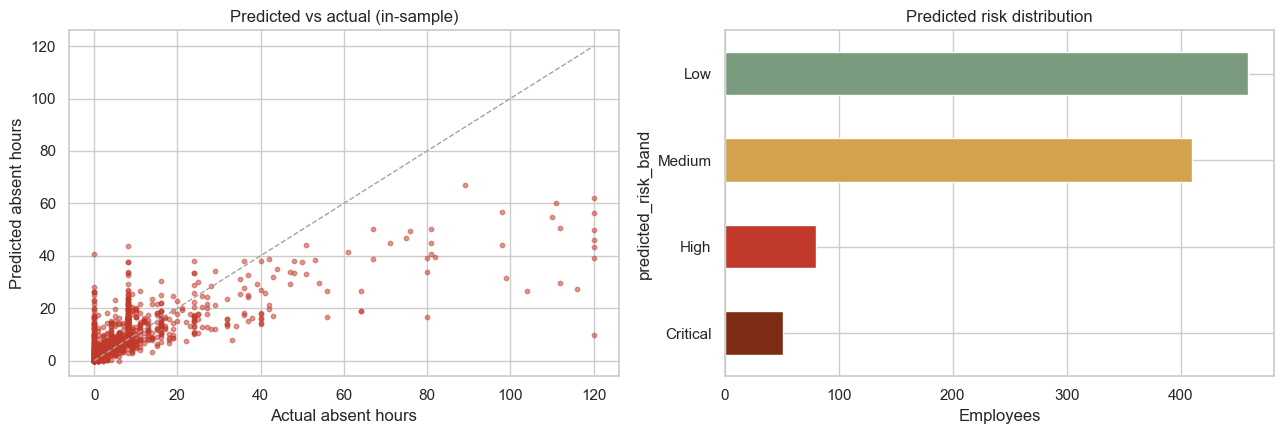

In [6]:
preds = result.predictions
y_true = preds['actual_absent_hours']
y_pred = preds['predicted_absent_hours']

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(y_true, y_pred, s=10, alpha=0.5, color='#C0392B')
lim = max(y_true.max(), y_pred.max())
ax[0].plot([0, lim], [0, lim], color='#A8A29E', linestyle='--', linewidth=1)
ax[0].set_xlabel('Actual absent hours')
ax[0].set_ylabel('Predicted absent hours')
ax[0].set_title('Predicted vs actual (in-sample)')

preds['predicted_risk_band'].value_counts().reindex(['Critical', 'High', 'Medium', 'Low']).plot(
    kind='barh', ax=ax[1], color=['#7C2D14', '#C0392B', '#D4A24C', '#7A9B7E']
)
ax[1].set_xlabel('Employees')
ax[1].set_title('Predicted risk distribution')
plt.tight_layout()
plt.show()

## 5. Global feature importance (SHAP)

Mean absolute SHAP value per feature on the regression model. Read it as: on average, how many hours of predicted absence does this feature swing per employee?

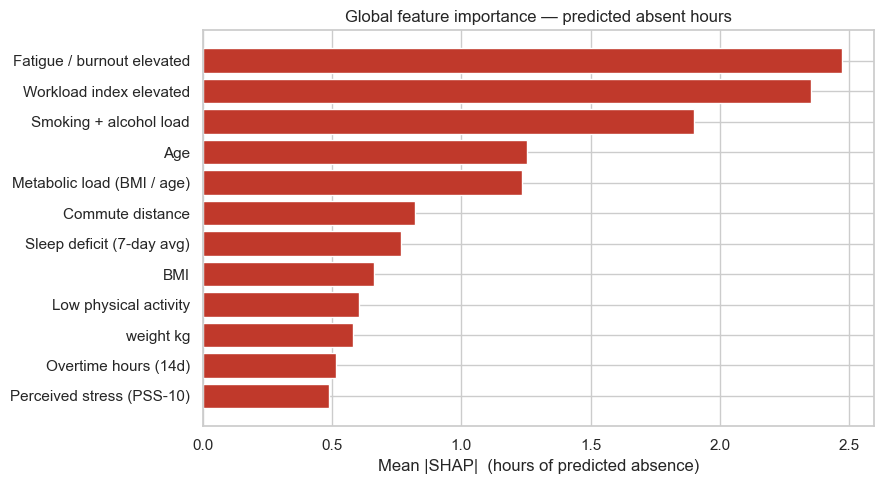

,feature,feature_label,mean_abs_shap
0,num__fatigue_burnout_score,Fatigue / burnout elevated,2.473522
1,num__workload_index_current,Workload index elevated,2.354072
2,num__smoker_alcohol_load,Smoking + alcohol load,1.898886
3,num__age,Age,1.253466
4,num__metabolic_load,Metabolic load (BMI / age),1.232946
5,num__distance_from_work_km,Commute distance,0.818949
6,num__sleep_hours_avg_7d,Sleep deficit (7-day avg),0.764933
7,num__bmi,BMI,0.661402
8,num__physical_activity_days_per_week,Low physical activity,0.603172
9,num__weight_kg,weight kg,0.581654


In [7]:
imp = result.explanations['global_importance'].head(12).copy()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp['feature_label'][::-1], imp['mean_abs_shap'][::-1], color='#C0392B')
ax.set_xlabel('Mean |SHAP|  (hours of predicted absence)')
ax.set_title('Global feature importance: predicted absent hours')
plt.tight_layout()
plt.show()
imp

## 5b. Fatigue and burnout as a lever

The model picks up `fatigue_burnout_score`, a composite of sleep deficit, overtime hours, consecutive shifts worked, days since last leave, workload, and the PSS-10 stress score, and it uses that composite alongside the underlying inputs. SHAP then surfaces the score as one of the strongest levers in the model, which means interventions that target sleep, shift design, or leave policy are the ones with the most predictable impact on absence.

When real Glencore data arrives, this composite is computed automatically the moment any of those inputs land in the feed.

In [8]:
imp = result.explanations['global_importance']
fatigue_family = imp[imp['feature'].str.contains(
    'fatigue|sleep_hours|overtime_hours|consecutive_shifts|days_since_last_leave|perceived_stress', case=False
)].copy()
fatigue_family['mean_abs_shap'] = fatigue_family['mean_abs_shap'].round(3)
print('Fatigue-family features in the model:')
print(fatigue_family[['feature_label', 'mean_abs_shap']].to_string(index=False))

print('\nFatigue / burnout segment across the cohort:')
for row in result.dashboard_feed['fatigue_burnout']['segment']:
    bar = '#' * int(row['share'] * 60)
    print(f"  {row['band']:9s} {row['count']:4d}  {row['share']*100:5.1f}%  {bar}")

print('\nFatigue summary stats:')
for k, v in result.dashboard_feed['fatigue_burnout']['summary'].items():
    print(f'  {k:25s} {v}')

Fatigue-family features in the model:
             feature_label  mean_abs_shap
Fatigue / burnout elevated          2.474
 Sleep deficit (7-day avg)          0.765
      Overtime hours (14d)          0.516
 Perceived stress (PSS-10)          0.489
 Consecutive shifts worked          0.249
     Days since last leave          0.097
        Fatigue band: high          0.025
         Fatigue band: low          0.000
    Fatigue band: critical          0.000
    Fatigue band: moderate          0.000

Fatigue / burnout segment across the cohort:
  Critical   177   17.7%  ##########
  High       393   39.3%  #######################
  Moderate   303   30.3%  ##################
  Low        127   12.7%  #######

Fatigue summary stats:
  mean                      52.9
  median                    53.7
  p90                       76.5
  share_high_or_critical    0.572


## 6. Per-employee intervention queue

The top 10 highest-predicted rows with their three biggest drivers attached. This is what the dashboard's intervention-queue panel reads from `dashboard_feed.json`.

In [9]:
queue = result.dashboard_feed['intervention_queue'][:10]
for i, row in enumerate(queue, 1):
    reasons = ' | '.join(f"{r['label']} (+{r['shap_hours']}h)" for r in row['top_reasons'])
    print(f"{i:2d}. emp {row['employee_id']:>7}  {row['predicted_risk_band']:8s}  "
          f"{row['predicted_absent_hours']:6.1f}h  ({row['predicted_absent_days_90d']:5.1f}d/90d)")
    print(f'      reasons: {reasons or "(none above zero)"}\n')

 1. emp  100631  Critical    67.0h  ( 25.1d/90d)
      reasons: Metabolic load (BMI / age) (+10.59h) | Sleep deficit (7-day avg) (+10.55h) | Smoking + alcohol load (+9.48h)

 2. emp  100199  Critical    62.0h  ( 23.2d/90d)
      reasons: Metabolic load (BMI / age) (+10.67h) | Sleep deficit (7-day avg) (+10.27h) | Age (+8.53h)

 3. emp  100275  Critical    60.1h  ( 22.6d/90d)
      reasons: Sleep deficit (7-day avg) (+12.85h) | Metabolic load (BMI / age) (+8.72h) | Smoking + alcohol load (+7.01h)

 4. emp  100037  Critical    56.8h  ( 21.3d/90d)
      reasons: Sleep deficit (7-day avg) (+13.27h) | Age (+6.35h) | Smoking + alcohol load (+5.72h)

 5. emp  100623  Critical    56.3h  ( 21.1d/90d)
      reasons: Smoking + alcohol load (+12.89h) | Workload index elevated (+5.72h) | Age (+4.1h)

 6. emp  100240  Critical    54.8h  ( 20.5d/90d)
      reasons: Sleep deficit (7-day avg) (+10.27h) | Smoking + alcohol load (+10.21h) | Fatigue / burnout elevated (+9.47h)

 7. emp       9  Critical  

## 7. Dashboard feed

What the dashboard (`index.html`) consumes directly. The shape mirrors the existing panel structure, with headline metrics, risk distribution, the intervention queue, global feature importance, data provenance, and model metrics.

In [10]:
feed = result.dashboard_feed
print('=== headline ===')
print(json.dumps(feed['headline'], indent=2))
print('\n=== risk_distribution ===')
print(json.dumps(feed['risk_distribution'], indent=2))
print('\n=== data_provenance ===')
print(json.dumps(feed['data_provenance'], indent=2))
print('\n=== model_metrics (regression) ===')
print(json.dumps(feed['model_metrics']['regression'], indent=2))

=== headline ===
{
  "covered_lives": 1000,
  "predicted_absent_days_90d": 4034.0,
  "predicted_absent_days_annual": 16138.0,
  "absence_cost_exposure_rand": 17751800.0,
  "projected_addressable_saving_rand": 745576.0,
  "fatigue_high_or_critical_share": 0.572
}

=== risk_distribution ===
[
  {
    "band": "Critical",
    "count": 51,
    "share": 0.051
  },
  {
    "band": "High",
    "count": 80,
    "share": 0.08
  },
  {
    "band": "Medium",
    "count": 410,
    "share": 0.41
  },
  {
    "band": "Low",
    "count": 459,
    "share": 0.459
  }
]

=== data_provenance ===
[
  {
    "source": "synthetic_mining_v1__glencore_sa_mining",
    "rows": 800
  },
  {
    "source": "uci_absenteeism",
    "rows": 200
  }
]

=== model_metrics (regression) ===
{
  "n_train": 1000,
  "cv_mae": 8.928,
  "cv_rmse": 16.598,
  "cv_r2": 0.178,
  "target_mean": 10.603,
  "target_std": 18.314
}


## 8. Sanity check: score a fresh batch

This demonstrates the production path. Imagine a small ad-hoc payload, in this case a single new employee record, fed through the same feature pipeline and then scored by the saved model. It is exactly the code path that will fire when a Glencore batch lands.

In [11]:
from welo_pipeline.features import build_features
from welo_pipeline.score import score

new_employee = pd.DataFrame([
    {
        'employee_id': 999_001,
        'age': 47, 'gender': 'M', 'marital_status': 'Married',
        'number_of_dependents': 3, 'number_of_children': 2,
        'education_level': 'Secondary', 'tenure_years': 12.0,
        'distance_from_work_km': 28.0, 'bmi': 33.4,
        'height_cm': 175.0, 'weight_kg': 102.0,
        'smoking_status': 'Daily', 'alcohol_frequency': 'Heavy',
        'physical_activity_days_per_week': 1,
        'workload_index_current': 310.0,
        'sleep_hours_avg_7d': 5.1,
        'overtime_hours_14d': 42.0,
        'consecutive_shifts_worked': 11,
        'days_since_last_leave': 210,
        'perceived_stress_score': 28,
        'absence_duration_hours': np.nan,
        'source_dataset': 'glencore_live_v1',
    }
])

bundle = build_features(new_employee, thresholds=config.target.risk_band_thresholds)
scored = score(bundle, models_dir=config.output.models_dir)
scored

,row_id,employee_id,source_dataset,predicted_absent_hours,predicted_absent_days_monthly,predicted_absent_days_90d,predicted_risk_band,fatigue_burnout_score,fatigue_band,prob_critical,prob_high,prob_low,prob_medium,actual_absent_hours,actual_risk_band
0,0,999001,glencore_live_v1,57.58,7.2,21.59,Critical,100.0,critical,0.9983,0.0004,0.0004,0.0009,NaN,NaN


## 9. What changes on day one of the Glencore feed

Three things, and only three. First, implement `welo_pipeline/adapters/glencore.py::GlencoreAdapter.load` so it reads the real export and renames the columns to the canonical schema. The column-rename map is already stubbed in the file. Second, copy `configs/demo.yaml` to `configs/glencore.yaml`, set `source.adapter` to `glencore`, point `source.path` at the file, and disable augmentation. Third, run `python -m welo_pipeline --config configs/glencore.yaml`.

Everything else, from feature engineering through model training and scoring to SHAP and the dashboard JSON, stays exactly as it is.